In [13]:
# 設定路徑、檢查資料夾
from pathlib import Path

# TODO: 改成你實際解壓後的資料夾路徑（建議用相對路徑）
# 例如：DATA_ROOT = Path("../data/raw")
DATA_ROOT = Path("../data/raw")

train_dir = DATA_ROOT / "seg_train" / "seg_train"
test_dir  = DATA_ROOT / "seg_test" / "seg_test"
pred_dir  = DATA_ROOT / "seg_pred" / "seg_pred"

print("DATA_ROOT:", DATA_ROOT.resolve())
print("train_dir exists:", train_dir.exists(), train_dir)
print("test_dir exists :", test_dir.exists(), test_dir)
print("pred_dir exists :", pred_dir.exists(), pred_dir)

# 類別資料夾（以 train 為準）
classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
print("classes:", classes)


DATA_ROOT: D:\VScode\train\DL_OutdoorSceneClassfier\data\raw
train_dir exists: True ..\data\raw\seg_train\seg_train
test_dir exists : True ..\data\raw\seg_test\seg_test
pred_dir exists : True ..\data\raw\seg_pred\seg_pred
classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
# 統計每類張數（train/test）
def count_images_by_class(split_dir: Path, classes: list[str]) -> dict:
    counts = {}
    for c in classes:
        cdir = split_dir / c
        if not cdir.exists():
            counts[c] = 0
            continue
        counts[c] = len([p for p in cdir.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    return counts

train_counts = count_images_by_class(train_dir, classes)
test_counts  = count_images_by_class(test_dir, classes)

print("Train counts:")
for k, v in train_counts.items():
    print(f"  {k:10s} {v}")

print("\nTest counts:")
for k, v in test_counts.items():
    print(f"  {k:10s} {v}")


Train counts:
  buildings  2191
  forest     2271
  glacier    2404
  mountain   2512
  sea        2274
  street     2382

Test counts:
  buildings  437
  forest     474
  glacier    553
  mountain   525
  sea        510
  street     501


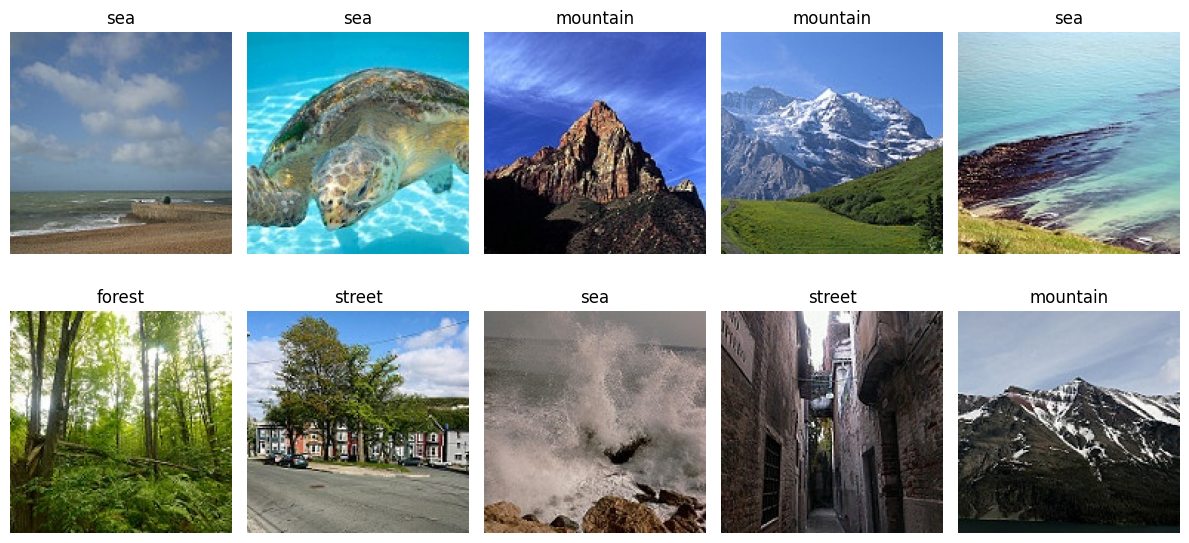

In [15]:
# 隨機顯示 10 張圖（含 label）
import random
from PIL import Image
import matplotlib.pyplot as plt

# 收集所有 train 圖片路徑
img_paths = []
for c in classes:
    img_paths += list((train_dir / c).glob("*.jpg"))

sample_paths = random.sample(img_paths, k=10)

plt.figure(figsize=(12, 6))
for i, p in enumerate(sample_paths, start=1):
    img = Image.open(p).convert("RGB")
    label = p.parent.name
    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [16]:
# 抽樣檢查影像尺寸
import numpy as np

sizes = []
for p in random.sample(img_paths, k=min(200, len(img_paths))):
    with Image.open(p) as im:
        sizes.append(im.size)  # (W, H)

ws = [s[0] for s in sizes]
hs = [s[1] for s in sizes]
print(f"Sampled {len(sizes)} images")
print(f"Width : min={min(ws)}, max={max(ws)}, mean={np.mean(ws):.1f}")
print(f"Height: min={min(hs)}, max={max(hs)}, mean={np.mean(hs):.1f}")


Sampled 200 images
Width : min=150, max=150, mean=150.0
Height: min=113, max=150, mean=149.6


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

train_dir = Path("../data/raw/seg_train")

# 取得所有類別名稱(資料夾名稱)
classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
print(classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
# 計算每個類別的影像數量
class_count = {}
for cls in classes:
    images = list((train_dir / cls).glob("*"))
    class_count[cls] = len(images)
class_count

{'buildings': 2191,
 'forest': 2271,
 'glacier': 2404,
 'mountain': 2512,
 'sea': 2274,
 'street': 2382}

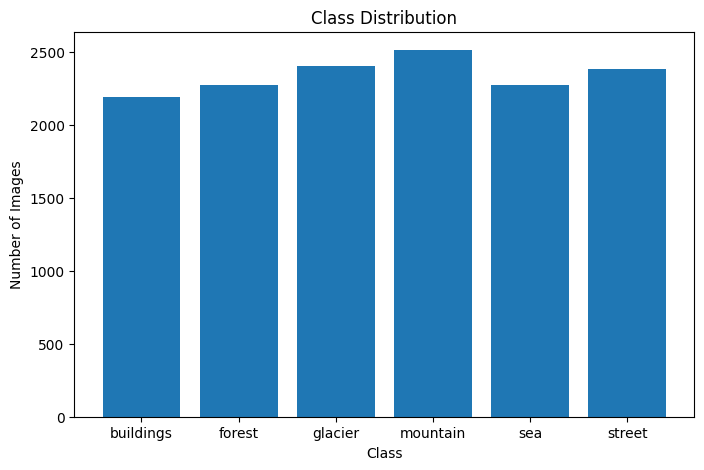

In [6]:
# 畫長條圖
plt.figure(figsize=(8, 5))
plt.bar(class_count.keys(), class_count.values())
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

In [7]:
# 定義顯示圖片的函式
def show_images_for_class(class_name, n=5):
    img_paths = list((train_dir / class_name).glob("*"))[:n]

    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(img_paths):
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)

    plt.show()


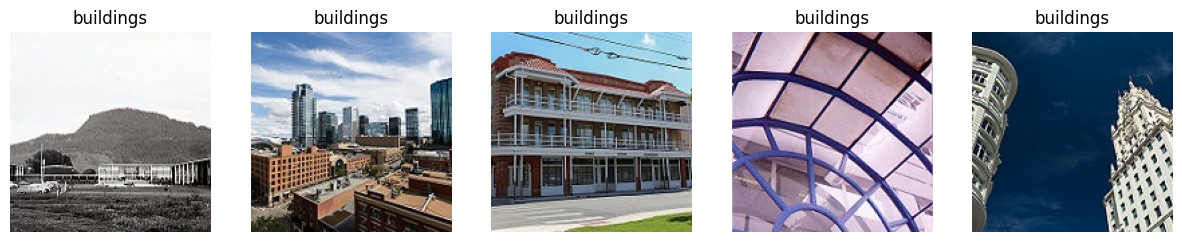

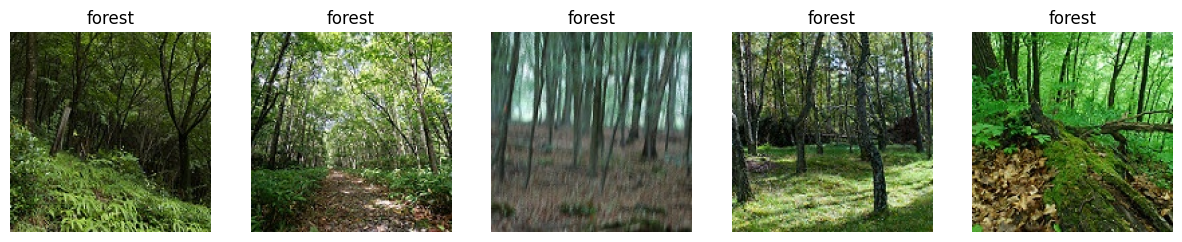

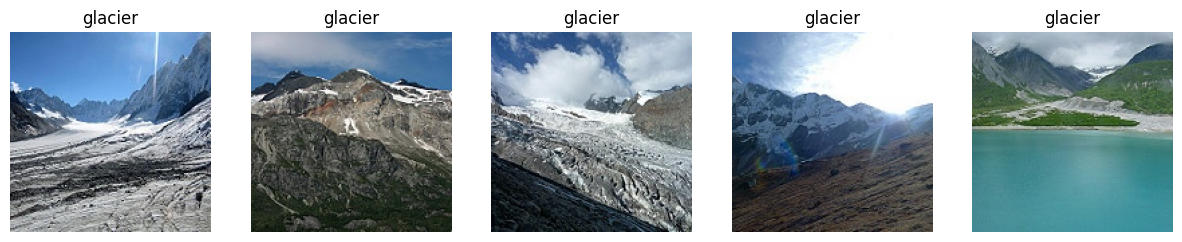

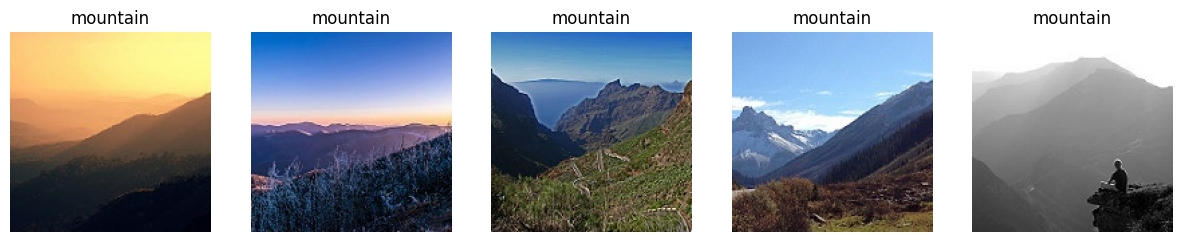

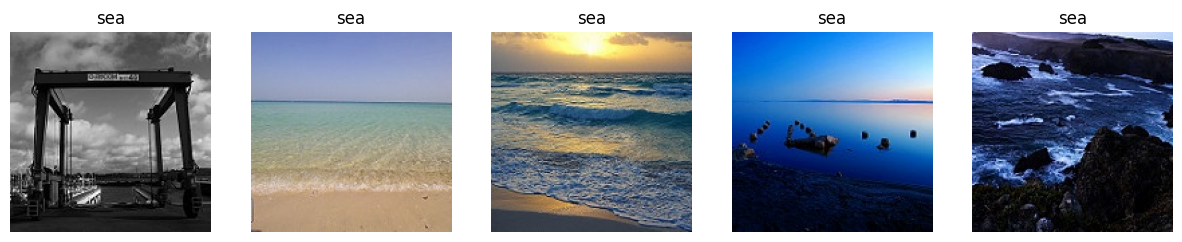

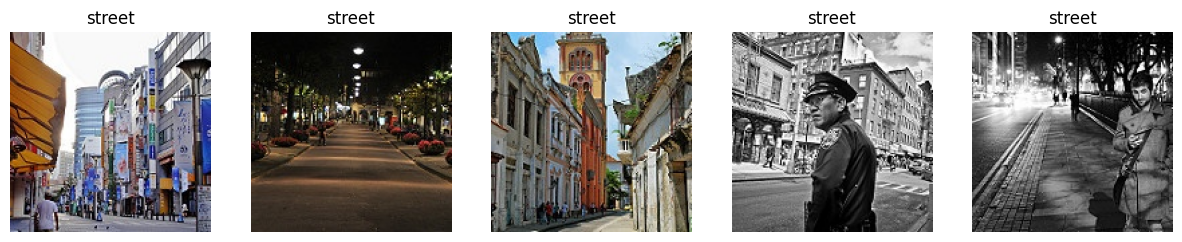

In [ ]:
# 對每個類別顯示5張
for cls in classes:
    show_images_for_class(cls, n=5)
